In [1]:
from pathlib import Path
import pandas as pd
from typing import List, Tuple
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import UnivariateSpline

In [2]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "mathtext.fontset": "dejavuserif"
})

In [7]:
def plot_quantum_mutual_information(
    file_paths: List[Path],
    labels: List[str] = None,
    smooth_factor: float = 0.005  # Adjust this to make the curve more or less rigid
):  
    # ---------------------------------------------------------
    # 1. Define Standard Pauli Matrices & Pauli Stack (q0 ⊗ q1)
    # ---------------------------------------------------------
    sigma_0 = np.eye(2, dtype=complex)
    sigma_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
    sigma_y = np.array([[0.0, -1j], [1j, 0.0]], dtype=complex)
    sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
    
    pauli_dict = {"I": sigma_0, "X": sigma_x, "Y": sigma_y, "Z": sigma_z}
    
    pauli_strings = [
        "IX", "IY", "IZ",
        "XI", "XX", "XY", "XZ", 
        "YI", "YX", "YY", "YZ",
        "ZI", "ZX", "ZY", "ZZ",
    ]
    
    # Standard ordering: "AB" -> np.kron(A, B)
    pauli_stack = np.stack([
        np.kron(pauli_dict[p[0]], pauli_dict[p[1]]) for p in pauli_strings
    ], axis=0) # Shape: (15, 4, 4)

    # ---------------------------------------------------------
    # 2. Information Theory Helper Functions
    # ---------------------------------------------------------
    def matrix_function(rho, fn, eps=1e-12):
        """Applies a scalar function to the eigenvalues of a batch of matrices."""
        eigvals, eigvecs = np.linalg.eigh(rho)
        eigvals = np.clip(eigvals, eps, None) # regularize to avoid log(0)
        D = np.zeros_like(rho)
        idx = np.arange(rho.shape[-1])
        D[..., idx, idx] = fn(eigvals)
        # Using swapaxes to safely handle batch dimensions
        return eigvecs @ D @ eigvecs.conj().swapaxes(-1, -2)

    def von_neumann_entropy(rho):
        """Computes S(rho) = -Tr(rho * log2(rho))."""
        log_rho = matrix_function(rho, np.log2)
        return -np.trace(rho @ log_rho, axis1=-2, axis2=-1).real

    # ---------------------------------------------------------
    # 3. Data Loading, Processing & Plotting
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 4.5), dpi=200)
    colors = ["#6a2c70", "#b83b5e", "#f08a5d", "#ffd460"]
    markers = ["P", "*", "X", "^"]
    
    for i, file in enumerate(file_paths):
        with np.load(file) as data:
            coherent_vec_mean = data["coherent_vec_mean"] # (T, 15)
            t_exp = data["time_us"]                       # (T,)
            
        # Reconstruct full density matrix rho_AB
        T = len(t_exp)
        rho_AB = np.eye(4, dtype=complex) / 4
        rho_AB = np.tile(rho_AB[None, :, :], (T, 1, 1))
        rho_AB = rho_AB + np.tensordot(coherent_vec_mean, pauli_stack, axes=[[1], [0]]) / 2
        
        # Enforce positive semi-definiteness & unit trace
        rho_AB = matrix_function(rho_AB, np.abs)
        rho_AB = rho_AB / np.trace(rho_AB, axis1=-2, axis2=-1)[:, None, None]
        
        # Take partial traces to get marginal states
        rho_A = np.trace(rho_AB.reshape(-1, 2, 2, 2, 2), axis1=2, axis2=4)
        rho_B = np.trace(rho_AB.reshape(-1, 2, 2, 2, 2), axis1=1, axis2=3)
        
        # Calculate QMI: I(A:B) = S(A) + S(B) - S(AB)
        S_A = von_neumann_entropy(rho_A)
        S_B = von_neumann_entropy(rho_B)
        S_AB = von_neumann_entropy(rho_AB)
        qmi = S_A + S_B - S_AB
        
        # -----------------------------------------------------
        # Curve Fitting (Smoothing Spline)
        # -----------------------------------------------------
        # Create a smooth interpolation of the noisy data
        spline = UnivariateSpline(t_exp, qmi, s=smooth_factor)
        t_smooth = np.linspace(min(t_exp), max(t_exp), 500)
        qmi_smooth = spline(t_smooth)
        
        label = labels[i] if labels and i < len(labels) else f"Data {i}"
        label = label.split(", ")
        label = "".join([f"$|{sublabel}\\rangle$" for sublabel in label])
        
        color = colors[i % len(colors)]
        
        # Plot raw experimental data points lightly
        plt.plot(
            t_exp, 
            qmi, 
            marker=markers[i % len(markers)], 
            ls='',          # No line for raw data
            color=color, 
            alpha=0.6,      # Make raw data semi-transparent
            markersize=6
        )
        
        # Plot the beautifully smoothed fitted curve
        plt.plot(
            t_smooth, 
            qmi_smooth, 
            ls="-", 
            linewidth=1.5,  # Thicker line for the fit
            color=color, 
            label=label,
            alpha=0.7
        )
        
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.xlabel("$t$ $(\\mu s)$", fontsize=15)
    plt.ylabel("$I(A:B)_{\\rho}$", fontsize=15)
    plt.title("Evolution of Quantum Mutual Information", fontsize=18)
    plt.xlim(left=0.0)
    plt.ylim([0.0, 1.0]) 
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.legend(frameon=True, fontsize=15)
    plt.tight_layout()
    # plt.show()
    plt.savefig("images/qmi_evolution.pdf", dpi=300, bbox_inches='tight')

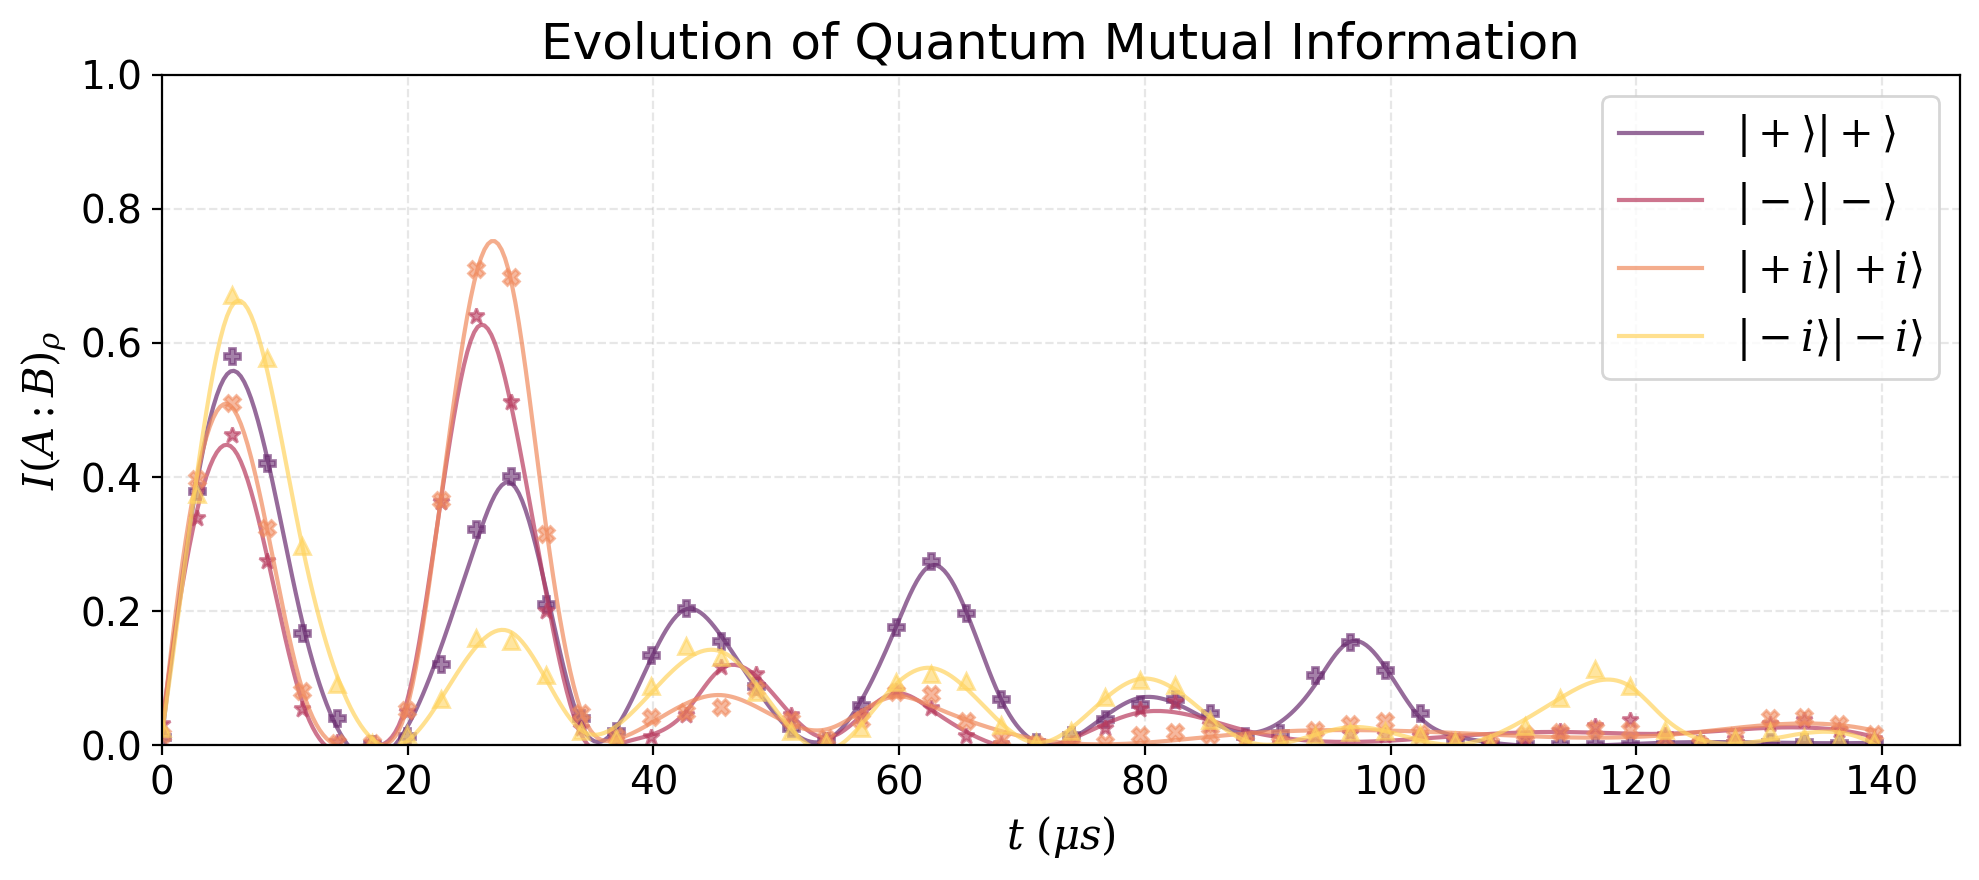

In [8]:
file_paths = [
    "results/state_tomography/two_qubit/ibm_sherbrooke/init+,+/q[26, 27]-np50-gpp50-s8192-2025-05-14T17-41-00.npz",
    "results/state_tomography/two_qubit/ibm_sherbrooke/init-,-/q[26, 27]-np50-gpp50-s8192-2025-05-14T18-23-07.npz",
    "results/state_tomography/two_qubit/ibm_sherbrooke/init+i,+i/q[26, 27]-np50-gpp50-s8192-2025-05-14T20-48-33.npz",
    "results/state_tomography/two_qubit/ibm_sherbrooke/init-i,-i/q[26, 27]-np50-gpp50-s8192-2025-05-15T01-34-11.npz"
]

labels = [
    "+, +", "-, -", "+i, +i", "-i, -i"
]


plot_quantum_mutual_information(
    file_paths=file_paths,
    labels=labels,
)

In [28]:
def plot_quantum_conditional_entropy(
    file_paths: List[Path],
    labels: List[str] = None,
    smooth_factor: float = 0.0025  # Adjust this to make the curve more or less rigid
):  
    # ---------------------------------------------------------
    # 1. Define Standard Pauli Matrices & Pauli Stack (q0 ⊗ q1)
    # ---------------------------------------------------------
    sigma_0 = np.eye(2, dtype=complex)
    sigma_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
    sigma_y = np.array([[0.0, -1j], [1j, 0.0]], dtype=complex)
    sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
    
    pauli_dict = {"I": sigma_0, "X": sigma_x, "Y": sigma_y, "Z": sigma_z}
    
    pauli_strings = [
        "IX", "IY", "IZ",
        "XI", "XX", "XY", "XZ", 
        "YI", "YX", "YY", "YZ",
        "ZI", "ZX", "ZY", "ZZ",
    ]
    
    # Standard ordering: "AB" -> np.kron(A, B)
    pauli_stack = np.stack([
        np.kron(pauli_dict[p[0]], pauli_dict[p[1]]) for p in pauli_strings
    ], axis=0) # Shape: (15, 4, 4)

    # ---------------------------------------------------------
    # 2. Information Theory Helper Functions
    # ---------------------------------------------------------
    def matrix_function(rho, fn, eps=1e-12):
        """Applies a scalar function to the eigenvalues of a batch of matrices."""
        eigvals, eigvecs = np.linalg.eigh(rho)
        eigvals = np.clip(eigvals, eps, None) # regularize to avoid log(0)
        D = np.zeros_like(rho)
        idx = np.arange(rho.shape[-1])
        D[..., idx, idx] = fn(eigvals)
        # Using swapaxes to safely handle batch dimensions
        return eigvecs @ D @ eigvecs.conj().swapaxes(-1, -2)

    def von_neumann_entropy(rho):
        """Computes S(rho) = -Tr(rho * log2(rho))."""
        log_rho = matrix_function(rho, np.log2)
        return -np.trace(rho @ log_rho, axis1=-2, axis2=-1).real

    # ---------------------------------------------------------
    # 3. Data Loading, Processing & Plotting
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 5))
    
    # You can customize these to match your style
    colors = ["#6a2c70", "#b83b5e", "#f08a5d", "#ffd460"]
    markers = ["P", "*", "X", "^"]
    
    for i, file in enumerate(file_paths):
        with np.load(file) as data:
            coherent_vec_mean = data["coherent_vec_mean"] # (T, 15)
            t_exp = data["time_us"]                       # (T,)
            
        # Reconstruct full density matrix rho_AB
        T = len(t_exp)
        rho_AB = np.eye(4, dtype=complex) / 4
        rho_AB = np.tile(rho_AB[None, :, :], (T, 1, 1))
        rho_AB = rho_AB + np.tensordot(coherent_vec_mean, pauli_stack, axes=[[1], [0]]) / 2
        
        # Enforce positive semi-definiteness & unit trace
        rho_AB = matrix_function(rho_AB, np.abs)
        rho_AB = rho_AB / np.trace(rho_AB, axis1=-2, axis2=-1)[:, None, None]
        
        # Take partial trace over A (axis 1 and 3) to get marginal state B
        # Standard convention: A is q0 (first index), B is q1 (second index)
        rho_B = np.trace(rho_AB.reshape(-1, 2, 2, 2, 2), axis1=1, axis2=3)
        
        # Calculate Quantum Conditional Entropy: S(A|B) = S(A,B) - S(B)
        S_B = von_neumann_entropy(rho_B)
        S_AB = von_neumann_entropy(rho_AB)
        qce = S_AB - S_B
        
        # -----------------------------------------------------
        # Curve Fitting (Smoothing Spline)
        # -----------------------------------------------------
        # Create a smooth interpolation of the noisy data
        spline = UnivariateSpline(t_exp, qce, s=smooth_factor)
        t_smooth = np.linspace(min(t_exp), max(t_exp), 500)
        qce_smooth = spline(t_smooth)
        
        label = labels[i] if labels and i < len(labels) else f"Data {i}"
        label = label.split(", ")
        label = "".join([f"$|{sublabel}\\rangle$" for sublabel in label])
        color = colors[i % len(colors)]
        
        # Plot raw experimental data points lightly
        plt.plot(
            t_exp, 
            qce, 
            marker=markers[i % len(markers)], 
            ls='',          # No line for raw data
            color=color, 
            alpha=0.6,      # Make raw data semi-transparent
            markersize=6
        )
        
        # Plot the beautifully smoothed fitted curve
        plt.plot(
            t_smooth, 
            qce_smooth, 
            ls="-", 
            linewidth=1.5,  # Thicker line for the fit
            color=color, 
            label=label,
            alpha=0.7
        )
        
    plt.xlabel("t $(\\mu s)$", fontsize=12)
    plt.ylabel("$S(A|B)_{\\rho}$", fontsize=12)
    plt.title("Evolution of Quantum Conditional Entropy", fontsize=14)
    
    # Adding a dashed line at y=0 to easily spot the quantum entanglement threshold
    plt.axhline(0, color='grey', linestyle='--', alpha=0.5, label="Entanglement Threshold")
    
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.legend(frameon=True, fontsize=11)
    plt.tight_layout()
    plt.show()

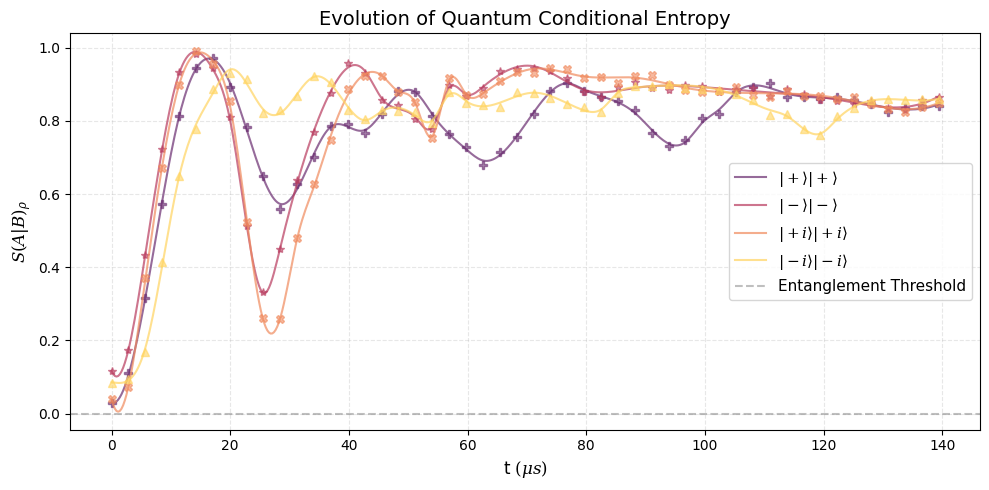

In [29]:
file_paths = [
    "results/state_tomography/two_qubit/ibm_sherbrooke/init+,+/q[26, 27]-np50-gpp50-s8192-2025-05-14T17-41-00.npz",
    "results/state_tomography/two_qubit/ibm_sherbrooke/init-,-/q[26, 27]-np50-gpp50-s8192-2025-05-14T18-23-07.npz",
    "results/state_tomography/two_qubit/ibm_sherbrooke/init+i,+i/q[26, 27]-np50-gpp50-s8192-2025-05-14T20-48-33.npz",
    "results/state_tomography/two_qubit/ibm_sherbrooke/init-i,-i/q[26, 27]-np50-gpp50-s8192-2025-05-15T01-34-11.npz"
]

labels = [
    "+, +", "-, -", "+i, +i", "-i, -i"
]


plot_quantum_conditional_entropy(
    file_paths=file_paths,
    labels=labels,
)